In [1]:
from google.colab import files

uploaded = files.upload()

Saving stroke_prediction_dataset.csv to stroke_prediction_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import pandas as pd

df = pd.read_csv("stroke_prediction_dataset.csv")

df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [ ]:
df.shape

(15000, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  object 
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  object 
 7   Work Type                 15000 non-null  object 
 8   Residence Type            15000 non-null  object 
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  object 
 12  Alcohol Intake            15000 non-null  object 
 13  Physical Activity         15000 non-null  object 
 14  Stroke

## Member 6 - Feature Engineering

### Introduction

Feature engineering is the process of creating new attributes from existing features to improve data quality and extract more meaningful information.

In this dataset, Blood Pressure Levels contains both systolic and diastolic blood pressure measurements in a single attribute. Therefore, it was separated into two independent numerical features.

In [ ]:
df['Blood Pressure Levels'].head()

,Blood Pressure Levels
0,140/108
1,146/91
2,154/97
3,174/81
4,121/95


In [ ]:
df[['Systolic_BP', 'Diastolic_BP']] = (
    df['Blood Pressure Levels']
    .str.split('/', expand=True)
)

df['Systolic_BP'] = pd.to_numeric(
    df['Systolic_BP']
)

df['Diastolic_BP'] = pd.to_numeric(
    df['Diastolic_BP']
)

In [ ]:
df[
    [
        'Blood Pressure Levels',
        'Systolic_BP',
        'Diastolic_BP'
    ]
].head()

,Blood Pressure Levels,Systolic_BP,Diastolic_BP
0,140/108,140,108
1,146/91,146,91
2,154/97,154,97
3,174/81,174,81
4,121/95,121,95


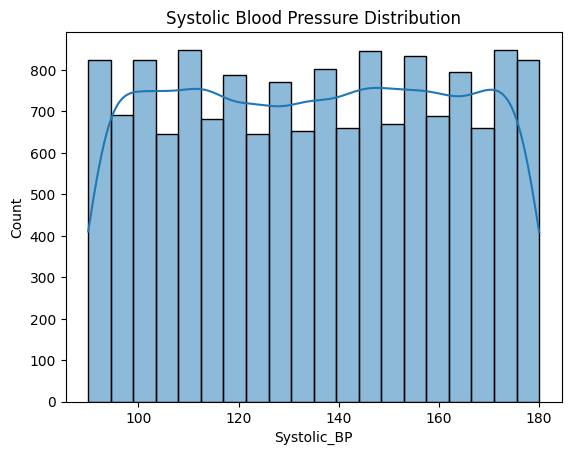

In [ ]:
sns.histplot(
    df['Systolic_BP'],
    bins=20,
    kde=True
)

plt.title("Systolic Blood Pressure Distribution")
plt.show()


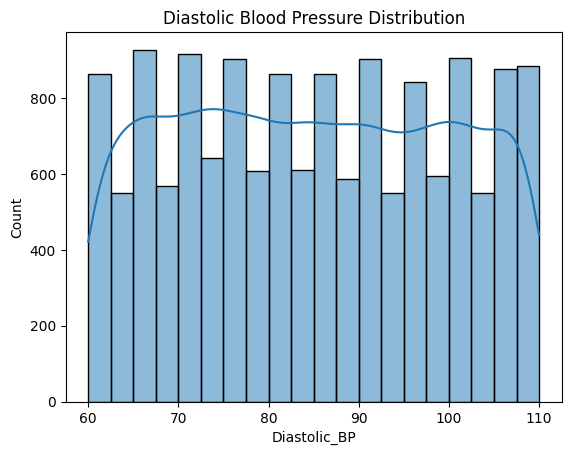

In [ ]:
sns.histplot(
    df['Diastolic_BP'],
    bins=20,
    kde=True
)

plt.title("Diastolic Blood Pressure Distribution")
plt.show()

### Feature Engineering Results

The Blood Pressure Levels attribute was successfully separated into two numerical features:

- Systolic_BP
- Diastolic_BP

The newly created attributes provide more detailed medical information and allow both blood pressure components to be analyzed independently.

The histograms indicate that both systolic and diastolic blood pressure values are reasonably distributed across the dataset.

## Conclusion

Feature engineering was successfully applied by extracting systolic and diastolic blood pressure values from the Blood Pressure Levels attribute.

This preprocessing step improved data representation by converting one combined feature into two meaningful numerical features, supporting future machine learning and predictive modeling tasks.